In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [3]:

def spring(start, end, nodes, width):
    """!
    Return a list of points corresponding to a spring.

    @param r1 (array-like) The (x, y) coordinates of the first endpoint.
    @param r2 (array-like) The (x, y) coordinates of the second endpoint.
    @param nodes (int) The number of spring "nodes" or coils.
    @param width (int or float) The diameter of the spring.
    @return An array of x coordinates and an array of y coordinates.
    """

    # Check that nodes is at least 1.
    nodes = max(int(nodes), 1)

    # Convert to numpy array to account for inputs of different types/shapes.
    start, end = np.array(start).reshape((2,)), np.array(end).reshape((2,))

    # If both points are coincident, return the x and y coords of one of them.
    if (start == end).all():
        return start[0], start[1]

    # Calculate length of spring (distance between endpoints).
    length = np.linalg.norm(np.subtract(end, start))

    # Calculate unit vectors tangent (u_t) and normal (u_t) to spring.
    u_t = np.subtract(end, start) / length
    u_n = np.array([[0, -1], [1, 0]]).dot(u_t)

    # Initialize array of x (row 0) and y (row 1) coords of the nodes+2 points.
    spring_coords = np.zeros((2, nodes + 2))
    spring_coords[:,0], spring_coords[:,-1] = start, end

    # Check that length is not greater than the total length the spring
    # can extend (otherwise, math domain error will result), and compute the
    # normal distance from the centerline of the spring.
    normal_dist = math.sqrt(max(0, width**2 - (length**2 / nodes**2))) / 2

    # Compute the coordinates of each point (each node).
    for i in range(1, nodes + 1):
        spring_coords[:,i] = (
            start
            + ((length * (2 * i - 1) * u_t) / (2 * nodes))
            + (normal_dist * (-1)**i * u_n))

    return spring_coords[0,:], spring_coords[1,:]

In [39]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 
    'font.size': 17              
})

(np.float64(-1.0), np.float64(2.8), np.float64(-2.0), np.float64(2.0))

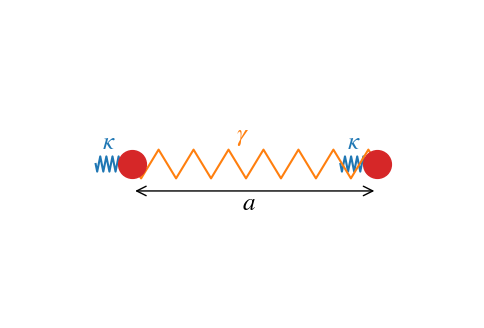

In [85]:
site1_coordx = 0
site1_coordy = 0 
site2_coordx = 2
site2_coordy = 0 
sp_len = 0.3
sp1x,sp1y = spring((site1_coordx-sp_len,site1_coordy), (site1_coordx, site1_coordy), 12, 0.2, )
sp2x,sp2y = spring((site2_coordx-sp_len,site2_coordy), (site2_coordx, site2_coordy), 12, 0.2, )
sp3x,sp3y = spring((site1_coordx, site1_coordx), (site2_coordx, site2_coordy), 14, 0.4)

fig, ax = plt.subplots(figsize=(6,4))
plt.text(site1_coordx-sp_len/1.2,site1_coordy+sp_len/1.5,r"$\kappa$",fontsize="18",color="tab:blue")
plt.text(site2_coordx-sp_len/1.2,site2_coordy+sp_len/1.5,r"$\kappa$",fontsize="18",color="tab:blue")
plt.text((site1_coordx+site2_coordx)/2-sp_len/2,(site1_coordy+site2_coordy)/2+sp_len,r"$\gamma$",fontsize="18",color="tab:orange")
plt.text(.9,-.6,r"$a$",fontsize="18",color="black")
ax.annotate("",
            xy=(0., -0.35), xycoords='data',
            xytext=(2, -.35), textcoords='data',
            arrowprops=dict(arrowstyle="<->"))
plt.scatter(site1_coordx, site1_coordy, s=400, color="tab:red",zorder=20)
plt.scatter(site2_coordx, site2_coordy, s=400, color="tab:red",zorder=20)
plt.plot(sp1x,sp1y,color="tab:blue")
plt.plot(sp2x,sp2y,color="tab:blue")
plt.plot(sp3x,sp3y,color="tab:orange")
plt.xlim(-1,2.8)
plt.ylim(-2,2)
plt.axis('off')
